# seleccion_modelo

Proyecto ARIMA / SARIMA / ARIMAX / SARIMAX
Modelación epidemiológica con variables meteorológicas.

In [1]:
import pandas as pd
import numpy as np

from scipy.stats import boxcox
from sklearn.preprocessing import PowerTransformer, StandardScaler
from sklearn.linear_model import LassoCV
from sklearn.metrics import mean_squared_error, mean_absolute_error

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX

import warnings
warnings.filterwarnings("ignore")

In [2]:
df_semanal_meteo_epi = pd.read_excel(r"C:\Users\usuario1\OneDrive - Universidad de Antioquia\UNIVERSIDAD DE ANTIOQUIA\Proyecto SAT Dengue\Bases de datos\Datos consolidados\datos_semanal_meteo_epi.xlsx")

In [3]:
df_procesados = df_semanal_meteo_epi.copy()

# Log
df_procesados['casos_ln'] = np.log(df_procesados['casos_dengue'] + 1)
df_procesados['prec_ln'] = np.log(df_procesados['prec'] + 1)
df_procesados['dias_lluvia_ln'] = np.log(df_procesados['dias_lluvia'] + 1)

# Box-Cox
vars_boxcox = ['temp', 'temp_max', 'temp_min', 'hum_esp', 'hum_rel',
               'vel_vi', 'vel_vi_max', 'vel_vi_min', 'uv']

for var in vars_boxcox:
    df_procesados[f'{var}_bc'], _ = boxcox(df_procesados[var])

# Yeo-Johnson
pt_soi = PowerTransformer(method='yeo-johnson')
pt_sst = PowerTransformer(method='yeo-johnson')

df_procesados['soi_yj'] = pt_soi.fit_transform(df_procesados[['soi']])
df_procesados['sst_yj'] = pt_sst.fit_transform(df_procesados[['sst']])

In [4]:
lags_dict = {
    'hum_esp_bc': range(1, 9),
    'hum_rel_bc': range(1, 9),
    'sst_yj': range(8, 13),
    'vel_vi_max_bc': range(1, 8),
    'vel_vi_bc': range(1, 8),
    'dias_lluvia_ln': range(1, 9),
    'prec_ln': range(4, 9),
    'temp_bc': range(1, 8),
    'temp_max_bc': range(1, 8)
}

df_modelo = df_procesados.copy()

for var, lags in lags_dict.items():
    for lag in lags:
        df_modelo[f"{var}_lag_{lag}"] = df_modelo[var].shift(lag)

In [5]:
df_final = df_modelo[['casos_ln'] + [col for col in df_modelo.columns if 'lag' in col]]
df_final = df_final.dropna()

y = df_final["casos_ln"]
X = df_final.drop(columns=["casos_ln"])

In [6]:
def evaluar(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    return rmse, mae, mape

In [7]:
arima_orders = [(1,1,0),(0,1,1),(1,1,1),(2,1,1),(1,1,2),(2,1,2)]

sarima_orders = [
    ((1,1,1),(1,1,1,52)),
    ((1,1,0),(1,1,1,52)),
    ((0,1,1),(1,1,1,52)),
    ((2,1,1),(1,1,1,52)),
    ((1,1,2),(1,1,1,52)),
    ((1,1,1),(0,1,1,52)),
    ((1,1,1),(1,1,0,52))
]

arimax_orders = [(1,1,0),(0,1,1),(1,1,1),(2,1,1),(1,1,2)]

sarimax_orders = [
    ((1,1,1),(1,1,1,52)),
    ((1,1,0),(1,1,1,52)),
    ((0,1,1),(1,1,1,52)),
    ((2,1,1),(1,1,1,52)),
    ((1,1,2),(1,1,1,52))
]

In [8]:
def correr_modelos(y_train, y_test, X_train=None, X_test=None):

    resultados = []

    # ARIMA
    for order in arima_orders:
        try:
            model = ARIMA(y_train, order=order).fit()
            pred = model.forecast(len(y_test))
            rmse, mae, mape = evaluar(y_test, pred)

            resultados.append({"Modelo": f"ARIMA{order}","RMSE": rmse,"MAE": mae,"MAPE": mape,"AIC": model.aic})
        except Exception as e:
            print("Error ARIMA", order, e)

    # SARIMA
    for order, seasonal in sarima_orders:
        try:
            model = SARIMAX(y_train, order=order, seasonal_order=seasonal).fit(disp=False)
            pred = model.forecast(len(y_test))
            rmse, mae, mape = evaluar(y_test, pred)

            resultados.append({"Modelo": f"SARIMA{order}{seasonal}","RMSE": rmse,"MAE": mae,"MAPE": mape,"AIC": model.aic})
        except Exception as e:
            print("Error SARIMA", order, e)

    # ARIMAX y SARIMAX
    if X_train is not None:
        for order in arimax_orders:
            try:
                model = SARIMAX(y_train, exog=X_train, order=order).fit(disp=False)
                pred = model.forecast(len(y_test), exog=X_test)
                rmse, mae, mape = evaluar(y_test, pred)

                resultados.append({"Modelo": f"ARIMAX{order}","RMSE": rmse,"MAE": mae,"MAPE": mape,"AIC": model.aic})
            except Exception as e:
                print("Error ARIMAX", order, e)

        for order, seasonal in sarimax_orders:
            try:
                model = SARIMAX(y_train, exog=X_train, order=order, seasonal_order=seasonal).fit(disp=False)
                pred = model.forecast(len(y_test), exog=X_test)
                rmse, mae, mape = evaluar(y_test, pred)

                resultados.append({"Modelo": f"SARIMAX{order}{seasonal}","RMSE": rmse,"MAE": mae,"MAPE": mape,"AIC": model.aic})
            except Exception as e:
                print("Error SARIMAX", order, e)

    return pd.DataFrame(resultados)

In [9]:
def ejecutar_pipeline(df, split_ratio):

    split = int(len(df) * split_ratio)

    y = df["casos_ln"]
    X = df.drop(columns=["casos_ln"])

    y_train, y_test = y[:split], y[split:]
    X_train, X_test = X[:split], X[split:]

    # Escalar
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # LASSO
    lasso = LassoCV(cv=5, random_state=42)
    lasso.fit(X_train_scaled, y_train)

    coef = pd.Series(lasso.coef_, index=X.columns)
    variables_sel = coef[coef != 0].index.tolist()

    print(f"\nVariables seleccionadas ({int(split_ratio*100)}%):")
    print(variables_sel)

    # Base reducida
    X_train_sel = pd.DataFrame(X_train_scaled, columns=X.columns, index=X_train.index)[variables_sel]
    X_test_sel = pd.DataFrame(X_test_scaled, columns=X.columns, index=X_test.index)[variables_sel]

    # Modelos
    resultados = correr_modelos(y_train, y_test, X_train_sel, X_test_sel)

    return resultados.sort_values("RMSE")

In [11]:
# 80/20
resultados_80 = ejecutar_pipeline(df_final, 0.8)
print("\nRESULTADOS 80/20")
print(resultados_80)


Variables seleccionadas (80%):
['hum_esp_bc_lag_1', 'hum_esp_bc_lag_2', 'hum_esp_bc_lag_3', 'hum_esp_bc_lag_4', 'hum_esp_bc_lag_5', 'hum_esp_bc_lag_6', 'hum_esp_bc_lag_7', 'hum_esp_bc_lag_8', 'hum_rel_bc_lag_1', 'hum_rel_bc_lag_2', 'hum_rel_bc_lag_3', 'hum_rel_bc_lag_4', 'hum_rel_bc_lag_5', 'hum_rel_bc_lag_6', 'hum_rel_bc_lag_7', 'sst_yj_lag_8', 'sst_yj_lag_10', 'sst_yj_lag_11', 'sst_yj_lag_12', 'vel_vi_max_bc_lag_2', 'vel_vi_max_bc_lag_3', 'vel_vi_max_bc_lag_4', 'vel_vi_max_bc_lag_5', 'vel_vi_max_bc_lag_6', 'vel_vi_max_bc_lag_7', 'vel_vi_bc_lag_1', 'vel_vi_bc_lag_2', 'vel_vi_bc_lag_3', 'vel_vi_bc_lag_4', 'vel_vi_bc_lag_5', 'vel_vi_bc_lag_6', 'vel_vi_bc_lag_7', 'dias_lluvia_ln_lag_1', 'dias_lluvia_ln_lag_2', 'dias_lluvia_ln_lag_4', 'dias_lluvia_ln_lag_5', 'dias_lluvia_ln_lag_6', 'dias_lluvia_ln_lag_7', 'dias_lluvia_ln_lag_8', 'prec_ln_lag_4', 'prec_ln_lag_6', 'prec_ln_lag_7', 'prec_ln_lag_8', 'temp_bc_lag_1', 'temp_bc_lag_2', 'temp_bc_lag_3', 'temp_bc_lag_4', 'temp_bc_lag_5', 'temp_bc

In [12]:
# 90/10
resultados_90 = ejecutar_pipeline(df_final, 0.9)
print("\nRESULTADOS 90/10")
print(resultados_90)


Variables seleccionadas (90%):
['hum_esp_bc_lag_1', 'hum_esp_bc_lag_2', 'hum_esp_bc_lag_3', 'hum_esp_bc_lag_4', 'hum_esp_bc_lag_5', 'hum_esp_bc_lag_6', 'hum_esp_bc_lag_7', 'hum_esp_bc_lag_8', 'hum_rel_bc_lag_1', 'hum_rel_bc_lag_2', 'hum_rel_bc_lag_3', 'hum_rel_bc_lag_4', 'hum_rel_bc_lag_5', 'hum_rel_bc_lag_6', 'hum_rel_bc_lag_7', 'hum_rel_bc_lag_8', 'sst_yj_lag_8', 'sst_yj_lag_9', 'sst_yj_lag_10', 'sst_yj_lag_11', 'sst_yj_lag_12', 'vel_vi_max_bc_lag_1', 'vel_vi_max_bc_lag_2', 'vel_vi_max_bc_lag_3', 'vel_vi_max_bc_lag_4', 'vel_vi_max_bc_lag_6', 'vel_vi_max_bc_lag_7', 'vel_vi_bc_lag_1', 'vel_vi_bc_lag_2', 'vel_vi_bc_lag_3', 'vel_vi_bc_lag_4', 'vel_vi_bc_lag_5', 'vel_vi_bc_lag_6', 'vel_vi_bc_lag_7', 'dias_lluvia_ln_lag_1', 'dias_lluvia_ln_lag_2', 'dias_lluvia_ln_lag_3', 'dias_lluvia_ln_lag_4', 'dias_lluvia_ln_lag_5', 'dias_lluvia_ln_lag_6', 'dias_lluvia_ln_lag_7', 'dias_lluvia_ln_lag_8', 'prec_ln_lag_4', 'prec_ln_lag_7', 'prec_ln_lag_8', 'temp_bc_lag_1', 'temp_bc_lag_2', 'temp_bc_lag_3',

In [18]:
# 95/5
resultados_95 = ejecutar_pipeline(df_final, 0.95)
print("\nRESULTADOS 95/5")
print(resultados_95)


Variables seleccionadas (95%):
['hum_esp_bc_lag_1', 'hum_esp_bc_lag_2', 'hum_esp_bc_lag_3', 'hum_esp_bc_lag_4', 'hum_esp_bc_lag_5', 'hum_esp_bc_lag_6', 'hum_esp_bc_lag_7', 'hum_esp_bc_lag_8', 'hum_rel_bc_lag_1', 'hum_rel_bc_lag_2', 'hum_rel_bc_lag_3', 'hum_rel_bc_lag_4', 'hum_rel_bc_lag_5', 'hum_rel_bc_lag_6', 'hum_rel_bc_lag_7', 'hum_rel_bc_lag_8', 'sst_yj_lag_8', 'sst_yj_lag_9', 'sst_yj_lag_10', 'sst_yj_lag_11', 'sst_yj_lag_12', 'vel_vi_max_bc_lag_1', 'vel_vi_max_bc_lag_2', 'vel_vi_max_bc_lag_3', 'vel_vi_max_bc_lag_4', 'vel_vi_max_bc_lag_5', 'vel_vi_max_bc_lag_6', 'vel_vi_max_bc_lag_7', 'vel_vi_bc_lag_1', 'vel_vi_bc_lag_2', 'vel_vi_bc_lag_3', 'vel_vi_bc_lag_4', 'vel_vi_bc_lag_5', 'vel_vi_bc_lag_6', 'vel_vi_bc_lag_7', 'dias_lluvia_ln_lag_1', 'dias_lluvia_ln_lag_2', 'dias_lluvia_ln_lag_3', 'dias_lluvia_ln_lag_4', 'dias_lluvia_ln_lag_5', 'dias_lluvia_ln_lag_6', 'dias_lluvia_ln_lag_7', 'dias_lluvia_ln_lag_8', 'prec_ln_lag_4', 'prec_ln_lag_5', 'prec_ln_lag_6', 'prec_ln_lag_8', 'temp_bc_l

In [12]:
from statsmodels.stats.diagnostic import acorr_ljungbox

In [13]:
def calcular_ljung(residuos, lags=20):
    ljung = acorr_ljungbox(residuos, lags=[lags], return_df=True)
    p_value = ljung['lb_pvalue'].values[0]
    return p_value

In [15]:
# ARIMAX con Ljung-Box
try:
    # ARIMAX con Ljung-Box
    split = int(len(df_final) * 0.8)

    y_train, y_test = y[:split], y[split:]
    X_train, X_test = X[:split], X[split:]

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    lasso = LassoCV(cv=5, random_state=42)
    lasso.fit(X_train_scaled, y_train)

    coef = pd.Series(lasso.coef_, index=X.columns)
    variables_sel = coef[coef != 0].index.tolist()

    X_train_sel = pd.DataFrame(X_train_scaled, columns=X.columns, index=X_train.index)[variables_sel]
    X_test_sel = pd.DataFrame(X_test_scaled, columns=X.columns, index=X_test.index)[variables_sel]

    resultados = []
    for order in arimax_orders:
        try:
            modelo = SARIMAX(y_train, exog=X_train_sel, order=order).fit(disp=False)

            pred = modelo.forecast(len(y_test), exog=X_test_sel)

            rmse, mae, mape = evaluar(y_test, pred)

            residuos = modelo.resid
            ljung_p = calcular_ljung(residuos)

            resultados.append({
                "Modelo": f"ARIMAX{order}",
                "RMSE": rmse,
                "MAE": mae,
                "MAPE": mape,
                "AIC": modelo.aic,
                "Ljung_Box_pvalue": ljung_p
            })

        except Exception as e:
            print("Error ARIMAX", order, e)

    resultados = pd.DataFrame(resultados).sort_values("RMSE")
    print(resultados)

    pred = modelo.forecast(len(y_test), exog=X_test)

    rmse, mae, mape = evaluar(y_test, pred)

    # 🔥 RESIDUOS DEL MODELO
    residuos = modelo.resid

    # 🔥 PRUEBA LJUNG-BOX
    ljung_p = calcular_ljung(residuos)

    resultados.append({
        "Modelo": f"ARIMAX{order}",
        "RMSE": rmse,
        "MAE": mae,
        "MAPE": mape,
        "AIC": modelo.aic,
        "Ljung_Box_pvalue": ljung_p
    })

except Exception as e:
    print("Error ARIMAX", order, e)

            Modelo      RMSE       MAE       MAPE         AIC  \
0  ARIMAX(1, 1, 0)  0.849900  0.645822  12.328813  244.660949   
1  ARIMAX(0, 1, 1)  0.870068  0.681828  12.008904  222.241404   
4  ARIMAX(1, 1, 2)  0.870308  0.690230  12.016774  224.277605   
2  ARIMAX(1, 1, 1)  0.872046  0.690773  12.032870  222.187564   
3  ARIMAX(2, 1, 1)  0.873871  0.693100  12.099700  223.946815   

   Ljung_Box_pvalue  
0          0.000426  
1          0.083555  
4          0.078664  
2          0.081453  
3          0.081483  
Error ARIMAX (1, 1, 2) Provided exogenous values are not of the appropriate shape. Required (50, 57), got (50, 62).


In [16]:
def calcular_ljung_multiple(residuos):
    ljung = acorr_ljungbox(residuos, lags=[10,15,20], return_df=True)
    return ljung

In [15]:
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Variable objetivo
y = df_final['casos_ln']

# Variables exógenas (las de LASSO)
# First, run LASSO to get the selected variables
split = int(len(df_final) * 0.8)
y_train, y_test = y[:split], y[split:]
X_train, X_test = X[:split], X[split:]

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lasso = LassoCV(cv=5, random_state=42)
lasso.fit(X_train_scaled, y_train)

coef = pd.Series(lasso.coef_, index=X.columns)
variables_lasso = coef[coef != 0].index.tolist()

X = df_final[variables_lasso]

# Split 80/20
train_size = int(len(y) * 0.8)

y_train, y_test = y[:train_size], y[train_size:]
X_train, X_test = X[:train_size], X[train_size:]

In [16]:
# ARIMA
modelo_arima = ARIMA(y_train, order=(1,1,0)).fit()
pred_arima = modelo_arima.forecast(steps=len(y_test))

# SARIMA
modelo_sarima = SARIMAX(y_train, order=(1,1,0),
                        seasonal_order=(1,1,1,52)).fit()
pred_sarima = modelo_sarima.forecast(steps=len(y_test))

# ARIMAX
modelo_arimax = SARIMAX(y_train, exog=X_train,
                        order=(1,1,1)).fit()
pred_arimax = modelo_arimax.forecast(steps=len(y_test), exog=X_test)

# SARIMAX
modelo_sarimax = SARIMAX(y_train, exog=X_train,
                         order=(1,1,0),
                         seasonal_order=(1,1,1,52)).fit()
pred_sarimax = modelo_sarimax.forecast(steps=len(y_test), exog=X_test)

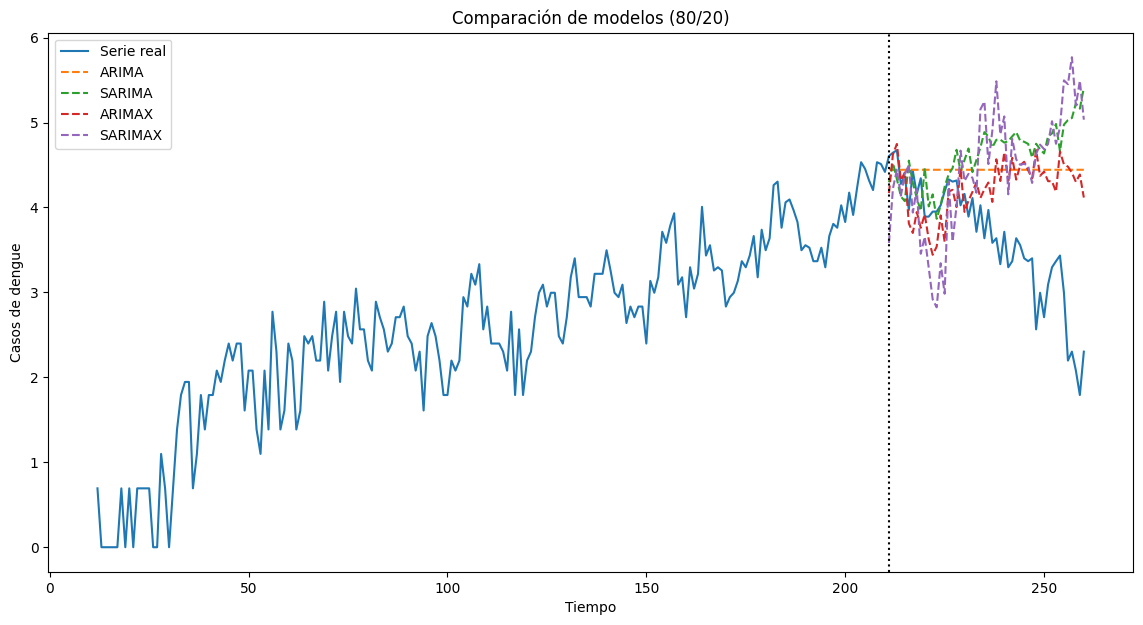

In [17]:
plt.figure(figsize=(14,7))

# Serie real
plt.plot(y.index, y, label='Serie real')

# Predicciones
plt.plot(y_test.index, pred_arima, '--', label='ARIMA')
plt.plot(y_test.index, pred_sarima, '--', label='SARIMA')
plt.plot(y_test.index, pred_arimax, '--', label='ARIMAX')
plt.plot(y_test.index, pred_sarimax, '--', label='SARIMAX')

# Línea de corte
plt.axvline(x=y.index[train_size], linestyle=':', color='black')

plt.title('Comparación de modelos (80/20)')
plt.xlabel('Tiempo')
plt.ylabel('Casos de dengue')
plt.legend()

plt.show()

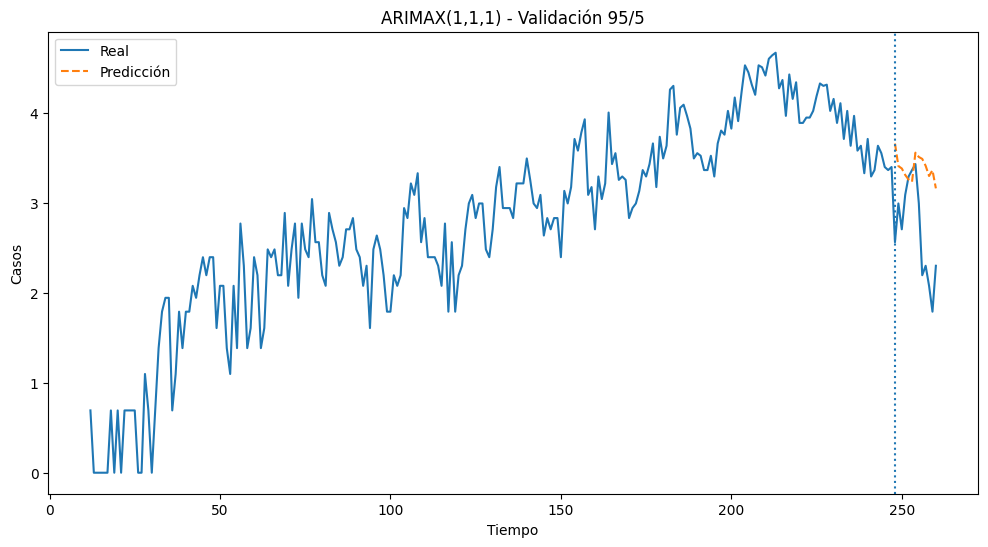

In [20]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Split 95/5
train_size = int(len(y) * 0.95)
y_train, y_test = y[:train_size], y[train_size:]
X_train, X_test = X[:train_size], X[train_size:]

# Modelo ganador
modelo = SARIMAX(y_train, exog=X_train, order=(1,1,1)).fit()

pred = modelo.forecast(steps=len(y_test), exog=X_test)

# Plot
plt.figure(figsize=(12,6))

plt.plot(y.index, y, label='Real')
plt.plot(y_test.index, pred, '--', label='Predicción')

plt.axvline(x=y.index[train_size], linestyle=':')

plt.title('ARIMAX(1,1,1) - Validación 95/5')
plt.xlabel('Tiempo')
plt.ylabel('Casos')
plt.legend()

plt.show()